# S&P 500 Sharpe Fit

## Data

In [ ]:
from pathlib import Path
import json
import hashlib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display

ROOT = Path.cwd()
DATA = ROOT / 'data' / 'sharpe_fit'
file = DATA / 'sp500_sharpe_1y.csv'
metadata = json.loads((DATA / 'provenance.json').read_text())
assert hashlib.sha256(file.read_bytes()).hexdigest() == metadata['sha256']
data = pd.read_csv(file, parse_dates=['date'])
dates = pd.DatetimeIndex(data['date'])
y = data['lambda'].to_numpy()
assert dates.is_unique and dates.is_monotonic_increasing and np.isfinite(y).all()
N = len(y)
DT = 1 / 252
T = np.arange(N) * DT
KS = (1, 2, 4)  # e.g. (4,), (2, 4), or tuple(range(1, 6))
if not KS or any(isinstance(k, bool) or not isinstance(k, (int, np.integer)) or k < 1 for k in KS):
    raise ValueError('KS must contain positive integers.')
KS = tuple(sorted(set(int(k) for k in KS)))
B_SEED = 20260909
INIT_SEED = 314159
N_STARTS = 24
MAX_ITER = 1200
ALPHA_MAX = 8 * np.pi
KAPPA_MAX = 3.0
# Preserve the original first three paths; extra dimensions have independent seeds.
def brownian_path(n, max_k, seed, dt):
    first = np.random.default_rng(seed).normal(size=(n-1, 3))
    columns = [first[:,j] for j in range(min(max_k, 3))]
    for j in range(3, max_k):
        columns.append(np.random.default_rng([seed,j]).normal(size=n-1))
    increments = np.column_stack(columns) * np.sqrt(dt)
    return np.vstack([np.zeros((1,max_k)), np.cumsum(increments,axis=0)])

B_all = brownian_path(N, max(KS), B_SEED, DT)
assert B_all.shape == (N, max(KS)) and np.all(B_all[0] == 0)
display(data.head())

        date    lambda
0 2017-09-11  1.896872
1 2017-09-12  1.782444
2 2017-09-13  2.017532
3 2017-09-14  2.010332
4 2017-09-15  1.917845


## Model

$A,\phi\in\mathbb{R}^{k\times k}$: diagonal = node terms, upper triangle = edges $r<s$; $\kappa\in\mathbb{R}^{k\times k}$, $\alpha\in\mathbb{R}^{k}$, $\lambda_0\in\mathbb{R}$.
The simulated $B_t$ is fixed with shared components across $k$; errors are in-sample, conditional on this path.

In [ ]:
def edges(k):
    return [(r, s) for r in range(k) for s in range(r + 1, k)]


def design(z, k, t=T, brownian=B_all):
    alpha = z[:k]
    kappa = z[k:].reshape(k, k)
    Y = t[:, None] * alpha + brownian[:, :k] @ kappa
    pairs = edges(k)
    angles = np.column_stack([Y] + [Y[:, r] - Y[:, s] for r, s in pairs])
    X = np.column_stack([np.ones(len(t)), np.cos(angles), np.sin(angles)])
    return X, angles


def objective(z, k, target=y, t=T, brownian=B_all):
    # Exact linear least squares for lambda_0, a=A*cos(phi), b=A*sin(phi).
    X, angles = design(z, k, t=t, brownian=brownian)
    beta, _, _, _ = np.linalg.lstsq(X, target, rcond=None)
    residual = X @ beta - target
    m = angles.shape[1]
    d_angle = -np.sin(angles) * beta[1:1+m] + np.cos(angles) * beta[1+m:]
    dY = d_angle[:, :k].copy()
    for j, (r, s) in enumerate(edges(k)):
        dY[:, r] += d_angle[:, k+j]
        dY[:, s] -= d_angle[:, k+j]
    weighted = (2 / len(target)) * residual[:, None] * dY
    gradient = np.r_[t @ weighted, (brownian[:, :k].T @ weighted).ravel()]
    return float(np.mean(residual ** 2)), gradient


def unpack(z, beta, k):
    m = k + len(edges(k))
    a, b = beta[1:1+m], beta[1+m:]
    A, phi = np.zeros((k, k)), np.zeros((k, k))
    for j, (r, s) in enumerate([(j, j) for j in range(k)] + edges(k)):
        A[r, s] = np.hypot(a[j], b[j])
        phi[r, s] = np.arctan2(b[j], a[j])
    return dict(lambda_0=float(beta[0]), A=A, phi=phi,
                alpha=z[:k].copy(), kappa=z[k:].reshape(k, k).copy())


def predict(p, t, brownian):
    k = len(p['alpha'])
    Y = t[:, None] * p['alpha'] + brownian[:, :k] @ p['kappa']
    fitted = np.full(len(t), p['lambda_0'])
    for j in range(k):
        fitted += p['A'][j,j] * np.cos(Y[:,j] - p['phi'][j,j])
    for r, s in edges(k):
        fitted += p['A'][r,s] * np.cos(Y[:,r] - Y[:,s] - p['phi'][r,s])
    return fitted

## Fit

Optimize $\alpha,\kappa$ with multiple starts; solve $a,b,\lambda_0$ by least squares at each step, then recover $A=\sqrt{a^2+b^2}$ and $\phi=\operatorname{atan2}(b,a)$.
Bounds: $|\alpha_j|\leq8\pi$, $|\kappa_{ij}|\leq3$; $t$ is in trading years.

In [ ]:
fits, run_rows = {}, []
rng = np.random.default_rng(INIT_SEED)
for k in KS:
    tic = time.perf_counter()
    starts = []
    if fits:
        previous_k = max(fits)
        previous = fits[previous_k]['parameters']
        alpha = np.r_[previous['alpha'], np.linspace(2*np.pi/1.5, 2*np.pi, k-previous_k)]
        kappa = np.zeros((k,k))
        kappa[:previous_k,:previous_k] = previous['kappa']
        starts.append(np.r_[alpha, kappa.ravel()])
    periods = np.array([0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.5, 6.0, 9.0])
    while len(starts) < N_STARTS:
        alpha = 2*np.pi/rng.choice(periods, size=k, replace=True) * rng.uniform(0.8,1.2,size=k)
        scale = (0.0, 0.15, 0.5, 1.0)[len(starts) % 4]
        kappa = np.clip(rng.normal(0,scale,(k,k)), -KAPPA_MAX, KAPPA_MAX)
        starts.append(np.r_[alpha,kappa.ravel()])
    bounds = [(-ALPHA_MAX,ALPHA_MAX)]*k + [(-KAPPA_MAX,KAPPA_MAX)]*(k*k)
    best = None
    for run, z0 in enumerate(starts):
        initial_mse = objective(z0, k)[0]
        opt = minimize(objective, z0, args=(k,), jac=True, method='L-BFGS-B',
                       bounds=bounds, options={'maxiter':MAX_ITER, 'ftol':1e-12,
                                               'gtol':1e-7, 'maxls':40})
        z = opt.x if np.isfinite(opt.fun) and opt.fun <= initial_mse else z0
        X, _ = design(z,k)
        beta, _, rank, singular = np.linalg.lstsq(X,y,rcond=None)
        predicted = X @ beta
        mse = float(np.mean((predicted-y)**2))
        run_rows.append(dict(k=k, start=run, mse=mse, initial_mse=initial_mse,
                             converged=bool(opt.success), iterations=int(opt.nit),
                             message=str(opt.message)))
        if best is None or mse < best['mse']:
            p = unpack(z,beta,k)
            np.testing.assert_allclose(predict(p,T,B_all),predicted,rtol=1e-8,atol=1e-8)
            best = dict(parameters=p, fitted=predicted, mse=mse, start=run,
                        converged=bool(opt.success), rank=int(rank),
                        condition_number=float(singular[0]/singular[-1]))
    fits[k] = best
    print(f"k={k} | RMSE={np.sqrt(best['mse']):.6f} | MSE={best['mse']:.6f} | {time.perf_counter()-tic:.1f}s", flush=True)

k=1 | RMSE=0.630419 | MSE=0.397428 | 0.2s
k=2 | RMSE=0.418913 | MSE=0.175488 | 2.0s
k=4 | RMSE=0.233095 | MSE=0.054333 | 56.0s


## Errors

In [ ]:
rows = []
for k, fit in fits.items():
    residual = fit['fitted']-y
    rows.append(dict(k=k, parameters=2*k*k+2*k+1, MSE=np.mean(residual**2),
                     RMSE=np.sqrt(np.mean(residual**2)), MAE=np.mean(np.abs(residual)),
                     R2=1-np.sum(residual**2)/np.sum((y-y.mean())**2),
                     best_start=fit['start'], converged=fit['converged'],
                     design_condition_number=fit['condition_number']))
errors = pd.DataFrame(rows).set_index('k')
print(f'Constant-mean baseline RMSE: {np.std(y):.6f}')
display(errors.round(6))

Constant-mean baseline RMSE: 0.848977


,parameters,MSE,RMSE,MAE,R2,best_start,converged,design_condition_number
k,,,,,,,,
1,5,0.397428,0.630419,0.515933,0.448601,3,True,1.566342
2,13,0.175488,0.418913,0.328092,0.756525,10,True,2.023732
4,41,0.054333,0.233095,0.176774,0.924617,5,False,90.005014


## Plots

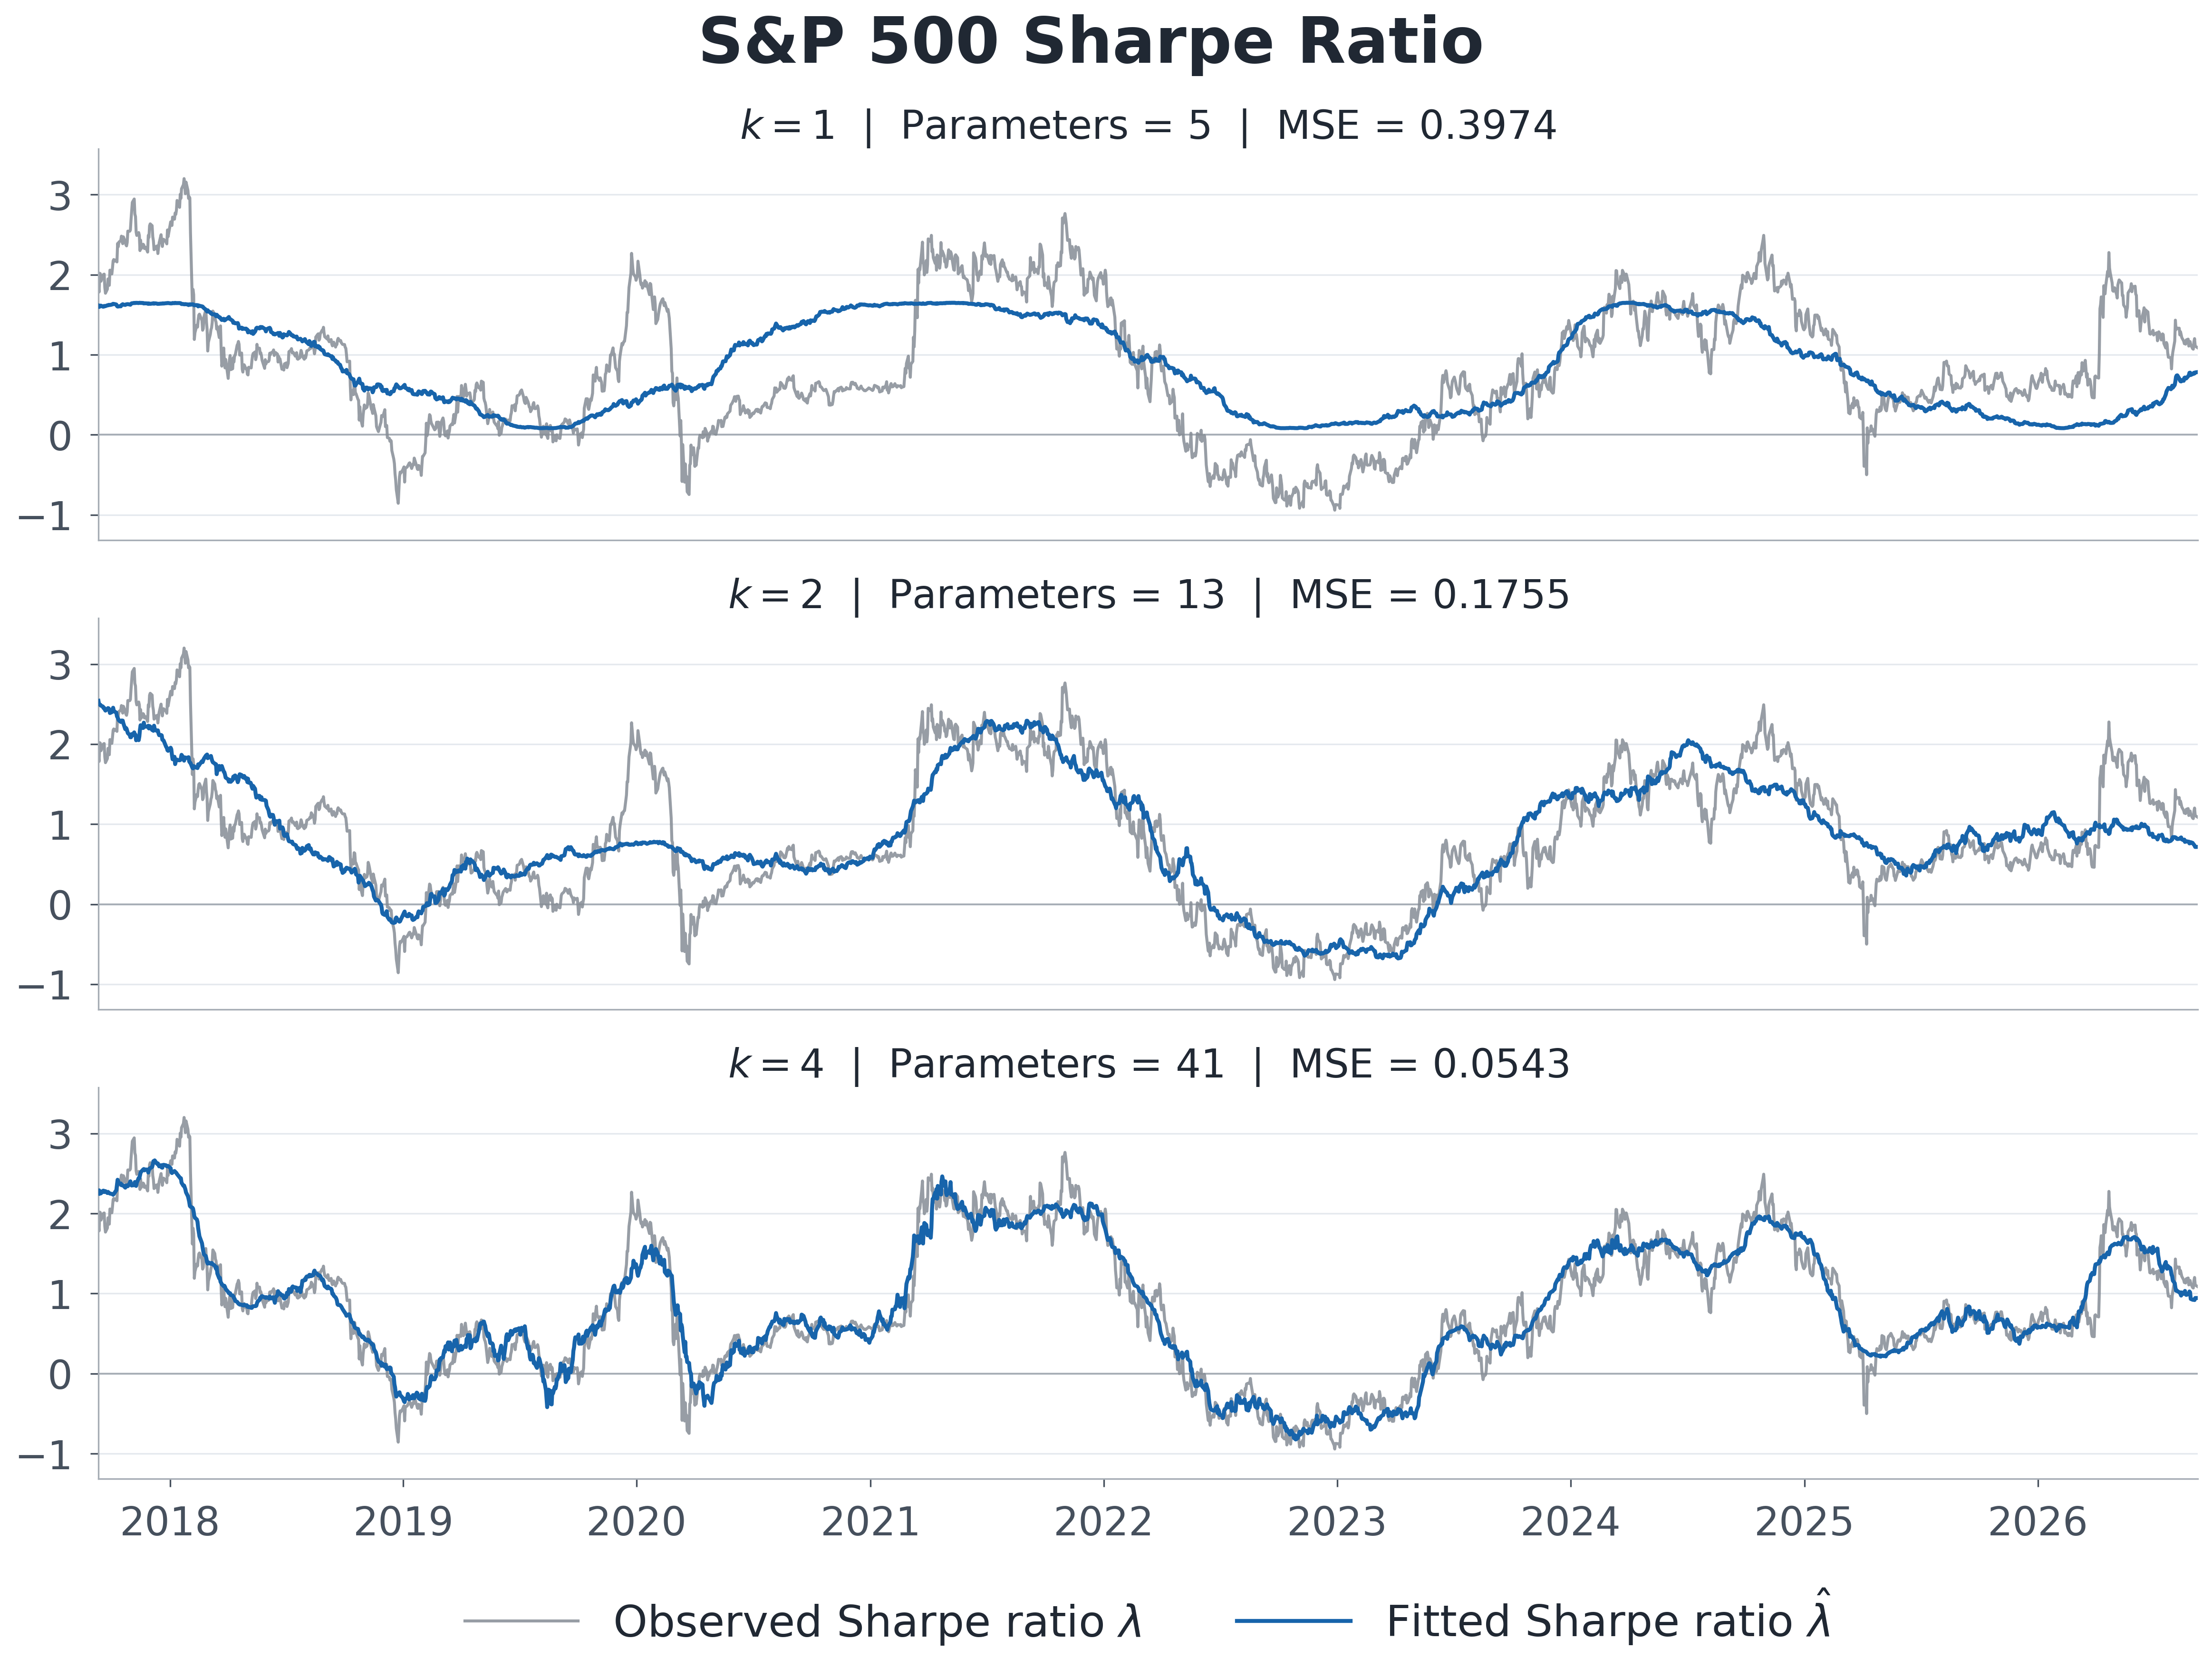

In [32]:
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Typography is specified at the exported figure size.
plot_style = {
    'font.family': 'DejaVu Sans',
    'font.size': 22,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22,
    'figure.titlesize': 32,
    'mathtext.fontset': 'dejavusans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#A6ADB5',
    'axes.linewidth': 0.8,
    'text.color': '#202833',
    'axes.labelcolor': '#202833',
    'xtick.color': '#46505D',
    'ytick.color': '#46505D',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'figure.dpi': 300,
    'savefig.dpi': 300,
}

with plt.rc_context(plot_style):
    fig, axes = plt.subplots(len(KS), 1, figsize=(16, 1.8 + 3.6*len(KS)),
                             sharex=True, sharey=True, squeeze=False)
    axes = axes[:, 0]
    fig.subplots_adjust(left=0.065, right=0.985, bottom=0.16,
                        top=0.9, hspace=0.2)
    fig.suptitle('S&P 500 Sharpe Ratio', y=0.975, weight='semibold')

    all_values = np.concatenate([y] + [fits[k]['fitted'] for k in KS])
    padding = 0.09 * np.ptp(all_values)
    limits = (all_values.min()-padding, all_values.max()+padding)
    for i, (ax, k) in enumerate(zip(axes, KS)):
        ax.set_axisbelow(True)
        ax.grid(axis='y', color='#E5E9EE', linewidth=0.8)
        ax.axhline(0, color='#A6ADB5', lw=0.9, zorder=1)
        ax.plot(dates, y, color='#858C95', lw=1.5, alpha=0.85,
                label=r'Observed Sharpe ratio $\lambda$', zorder=2)
        ax.plot(dates, fits[k]['fitted'], color='#1764AB', lw=2.0,
                label=r'Fitted Sharpe ratio $\hat{\lambda}$', zorder=3)
        ax.set_title(
            f"$k = {k}$  |  Parameters = {int(errors.loc[k, 'parameters'])}  |  "
            f"MSE = {errors.loc[k, 'MSE']:.4f}",
            loc='center', pad=0, fontsize=20)
        ax.set_ylabel('')
        ax.set_ylim(*limits)
        ax.set_xlim(dates[0], dates[-1])
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        ax.tick_params(axis='both', length=4, width=0.8, pad=9)
        ax.tick_params(axis='x', which='both', bottom=(i == len(KS)-1))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.525, 0.045),
               ncol=2, frameon=False, handlelength=2.6, columnspacing=2.2)

    figure_dir = ROOT / 'figures'
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_dir / 'Sharp_ratio_fit.png', bbox_inches='tight', facecolor='white')
    plt.show()
